# Exploratory Data Analysis (EDA)

This notebook performs a full exploratory analysis of the bank churn dataset.
It assumes the data has already been loaded and validated in `01_data_understanding.ipynb`.

## 0. Setup

In [2]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
df = pd.read_csv('C:/Users/Pablito/Desktop/2026.1_Python_FE/DataBase/Customer-Churn-Records.csv', sep = ',')

main_numeric_features = [
    "Age",
    "CreditScore",
    "Tenure",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts",
    "Satisfaction Score",
    "Point Earned"
]

binary_features = [
    "HasCrCard",
    "IsActiveMember",
    "Complain"
]

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns



## 1. Automated Profiling Report

The `data_profiling` library produces a full HTML report for a rapid overview of the dataset, useful as a starting point for EDA.

In [3]:
import data_profiling as dp

report = dp.ProfileReport(
    df,
    title="Churn_Bank_Record"
)

report.to_file("report.html")


c:\Users\Pablito\Desktop\2026.1_Python_FE\Churn_Bank_ENV\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 48.28it/s]


## 2. Overview All Numeric Features

Quick histogram grid covering every numeric column to spot shape and spread at a glance.

 **Note:** `RowNumber` and `CustomerId` are identifiers and should not be interpreted as meaningful numeric variables.

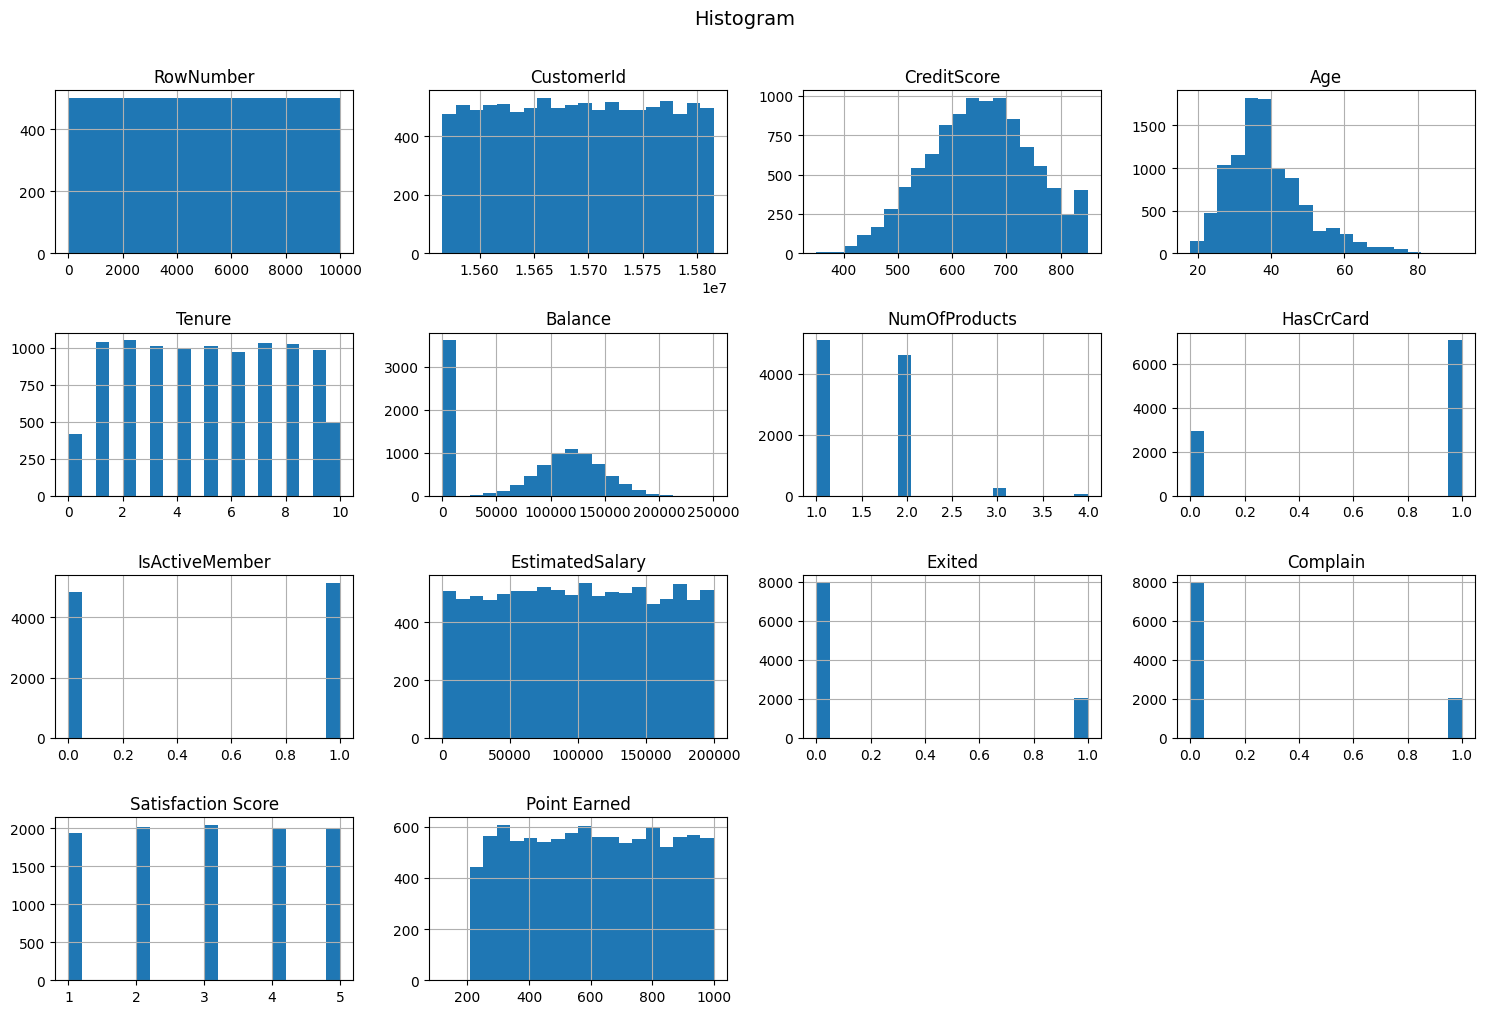

In [4]:
df[numeric_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle("Histogram", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Distributions Main Numeric Features

Individual histograms for relevant numeric variables.

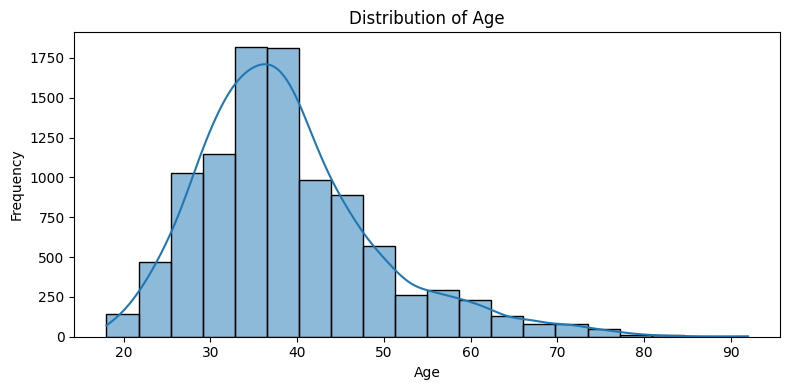

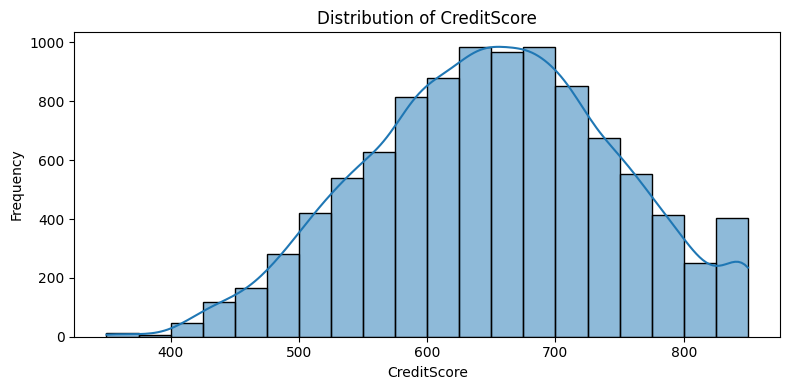

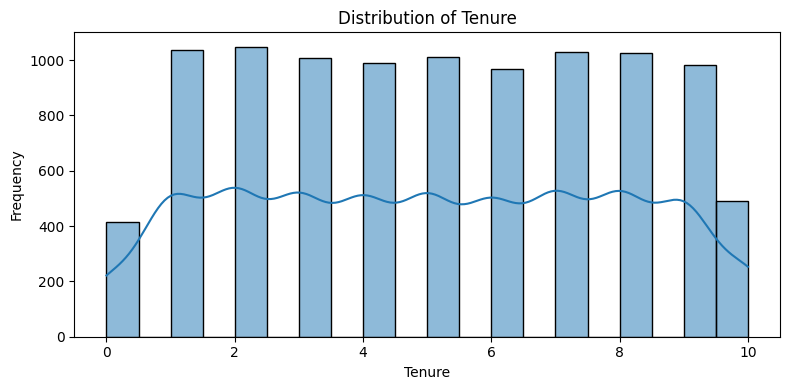

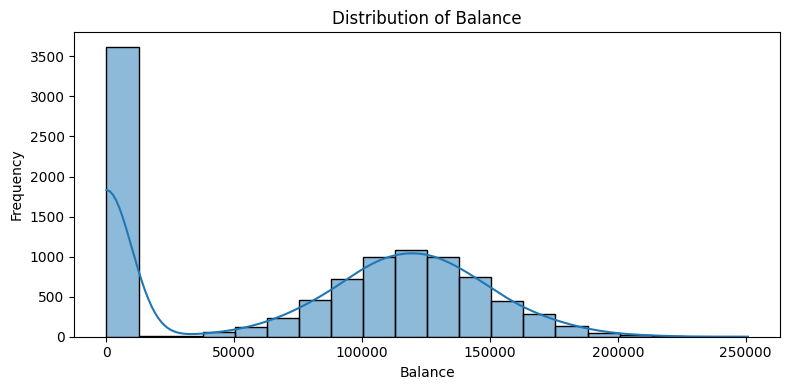

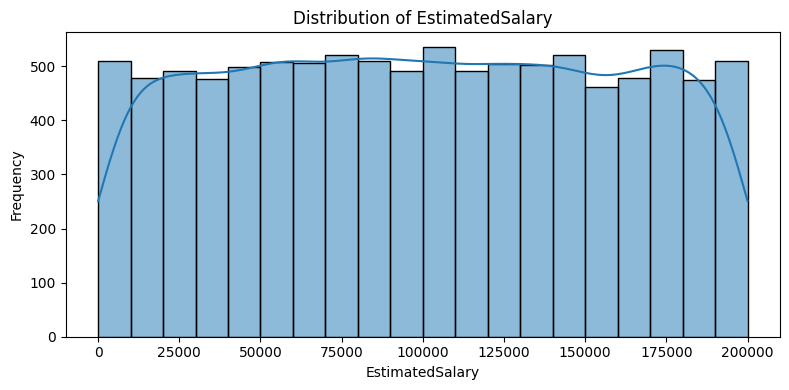

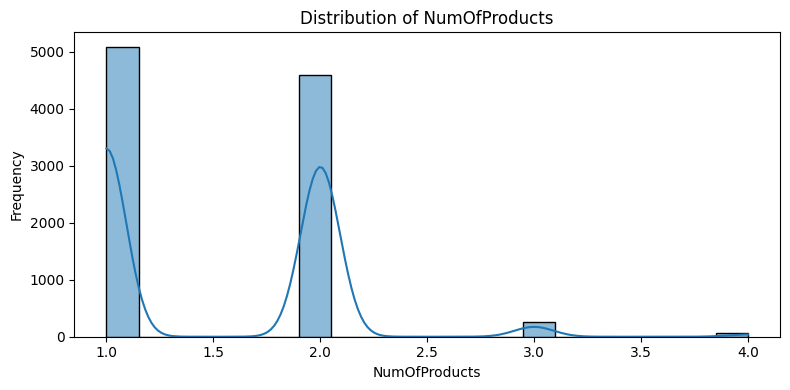

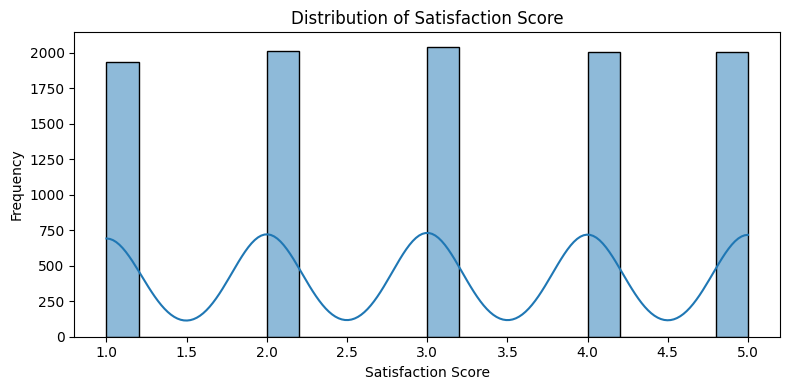

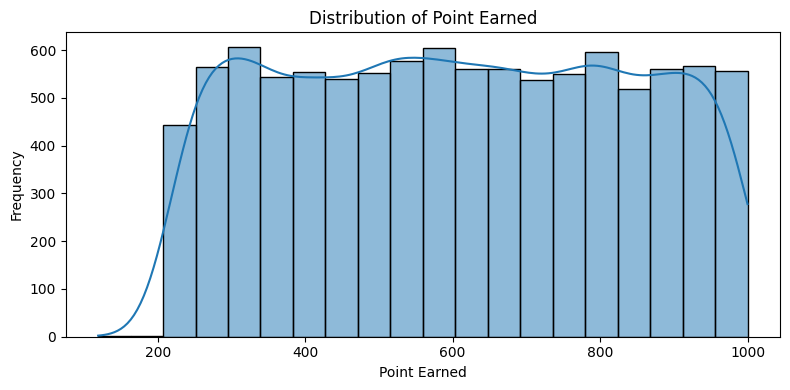

In [5]:
for col in main_numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 4. Outlier Detection Boxplots

Boxplots highlight the spread and potential outliers for each main numeric feature.

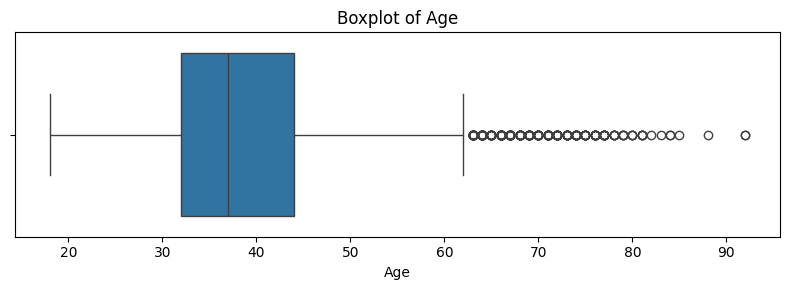

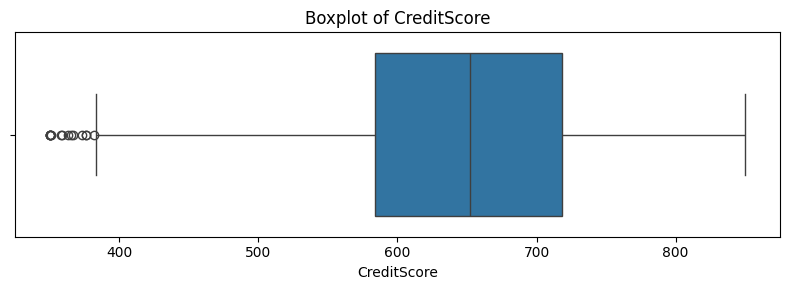

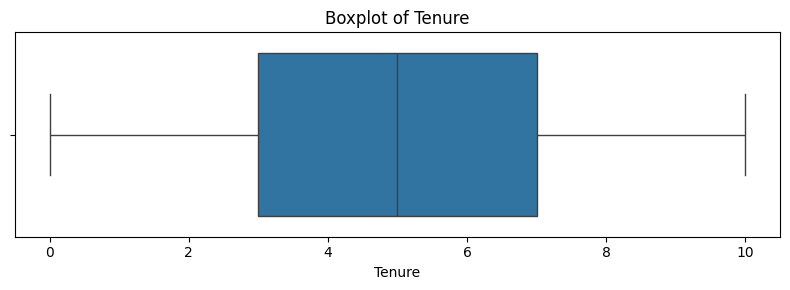

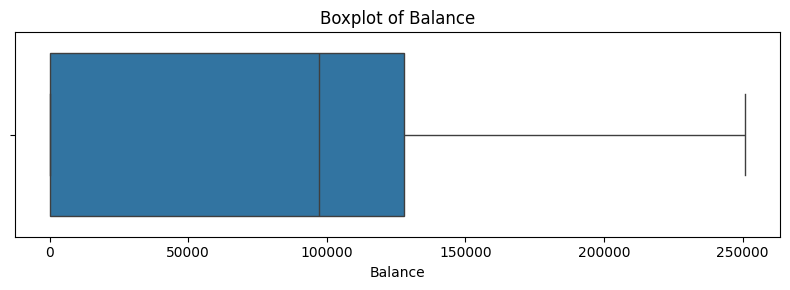

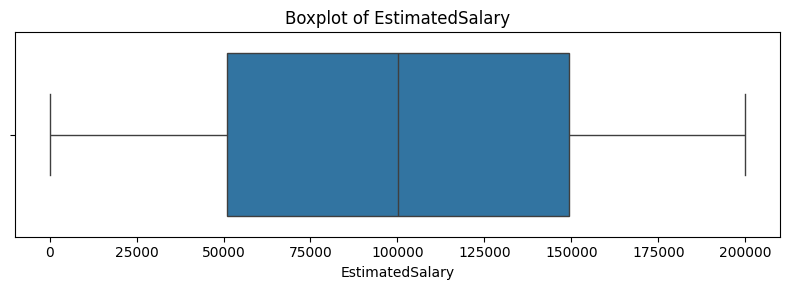

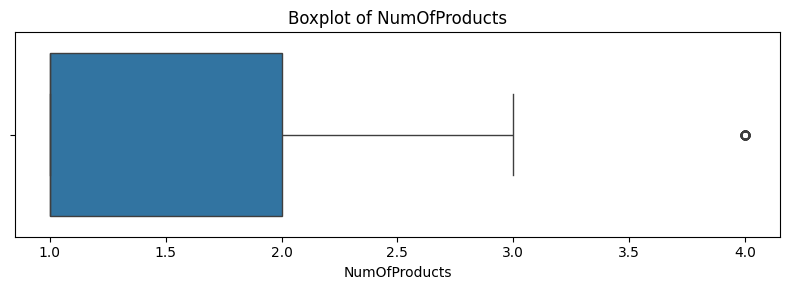

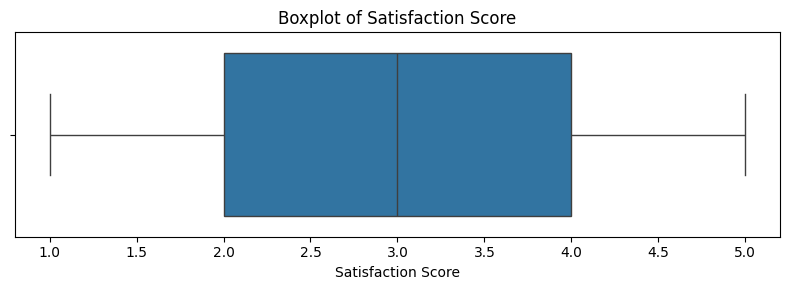

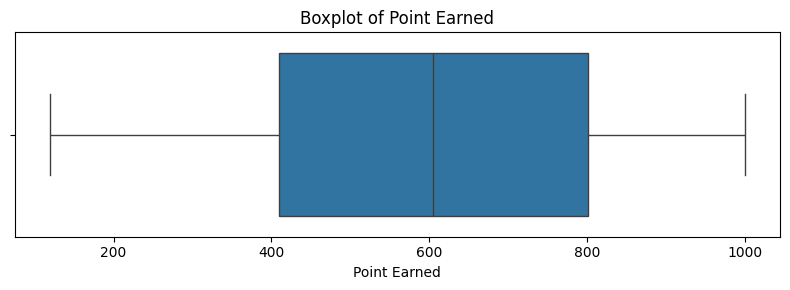

In [6]:
for col in main_numeric_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

## 5. Skewness Numeric Features

Skewness measures the asymmetry of a distribution:
- **> 0** : Right-skewed (tail on the right)
- **< 0** : Left-skewed (tail on the left)
- **= 0** : Approximately symmetric

In [7]:
skewness = (
    df[main_numeric_features]
    .skew()
    .sort_values(ascending=False)
    .rename("Skewness")
    .to_frame()
)

print(skewness)

                    Skewness
Age                 1.011320
NumOfProducts       0.745568
Tenure              0.010991
Point Earned        0.008344
EstimatedSalary     0.002085
Satisfaction Score -0.008936
CreditScore        -0.071607
Balance            -0.141109


## 6. Binary Features Count Plots

Distribution of the binary (0/1) indicator variables.

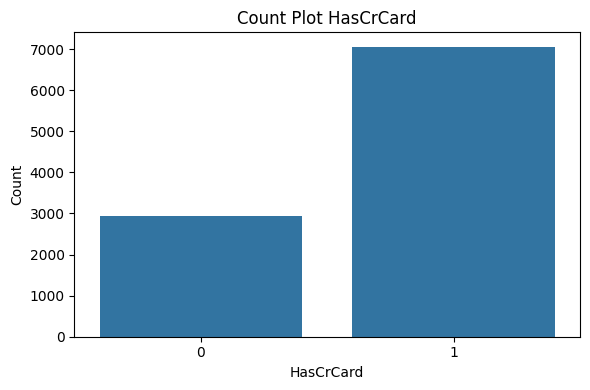

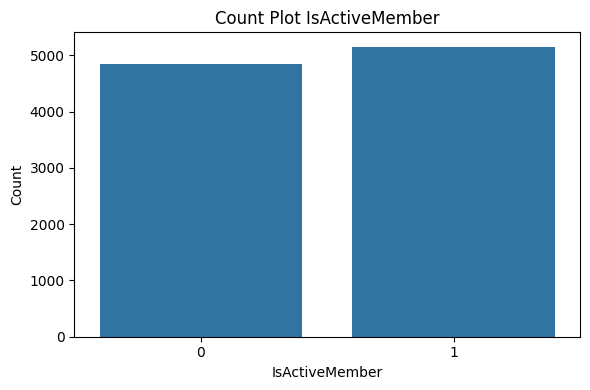

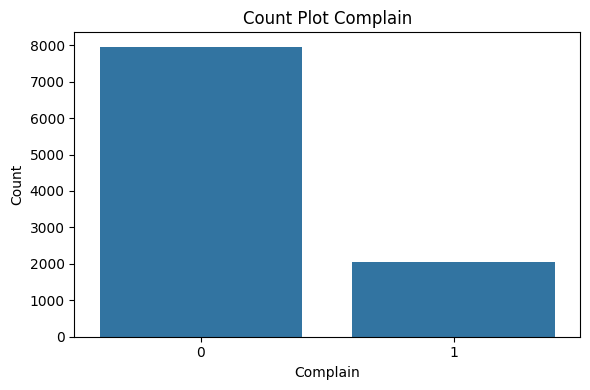

In [8]:
for col in binary_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 7. Correlation Analysis

Correlation analysis helps identify linear relationships
between numerical variables and detect potential multicollinearity.

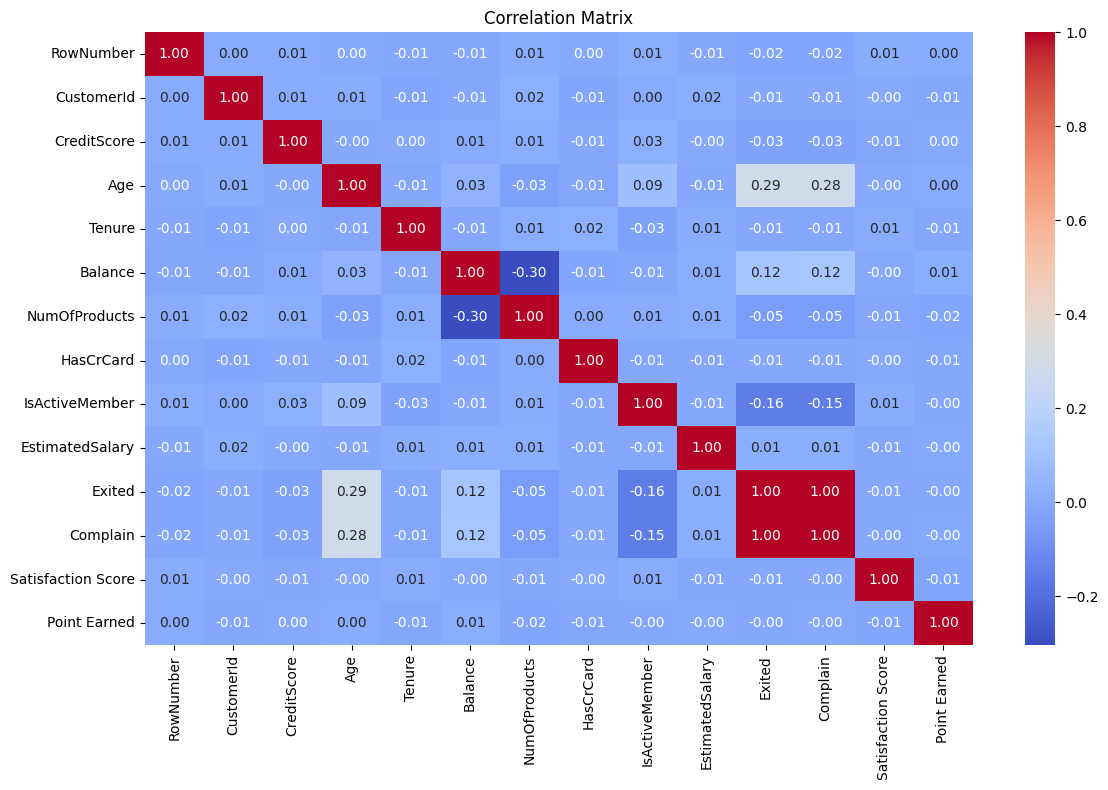

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [10]:
target_corr = (
    corr["Exited"]
    .sort_values(ascending=False)
    .to_frame()
)

print(target_corr)

                      Exited
Exited              1.000000
Complain            0.995693
Age                 0.285296
Balance             0.118577
EstimatedSalary     0.012490
Point Earned       -0.004628
Satisfaction Score -0.005849
CustomerId         -0.006203
HasCrCard          -0.006976
Tenure             -0.013656
RowNumber          -0.016140
CreditScore        -0.026771
NumOfProducts      -0.047611
IsActiveMember     -0.156356


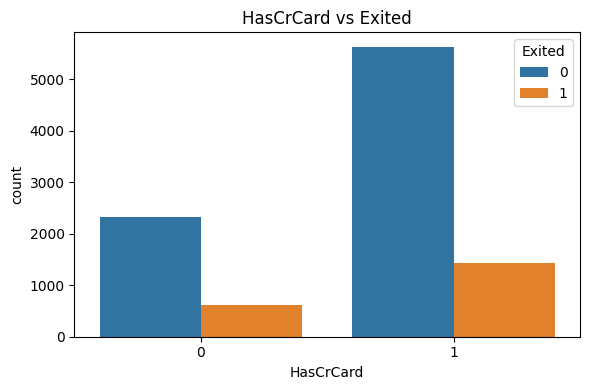

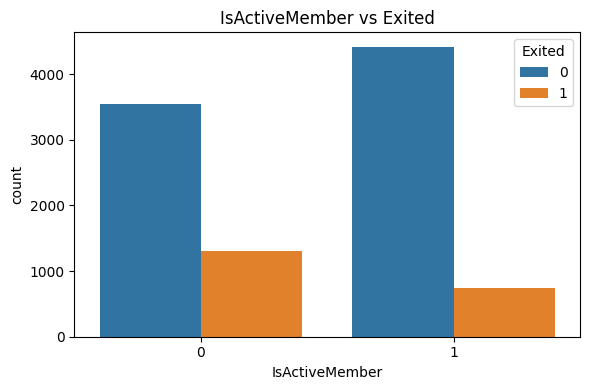

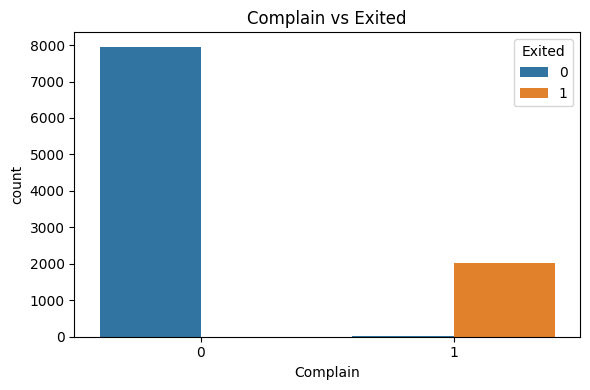

In [11]:
for col in binary_features:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        hue="Exited",
        data=df
    )

    plt.title(f"{col} vs Exited")

    plt.tight_layout()

    plt.show()

# 8. Conclusion 
Some numerical variables such as `NumOfProducts` and `Satisfaction Score` represent discrete integer values rather than continuous measurements, which explains their distribution patterns concentrated around a few specific categories.

Continuous variables such as `Age`, `Balance`, `CreditScore`, and `EstimatedSalary` exhibit smoother distributions with moderate asymmetry, which is more typical for financial and demographic data.

The boxplots reveal the presence of potential outliers, especially in `Age`, where older customers appear beyond the upper whisker, and in `CreditScore`, where lower credit values appear as left-tail outliers. `NumOfProducts` also contains a small number of extreme values, although most customers remain concentrated in lower product counts.

Correlation analysis shows generally weak linear relationships between variables. The strongest non-target correlation appears between `NumOfProducts` and `Balance` with a moderate negative relationship.

Regarding the target variable (`Exited`), `Complain` presents an extremely high positive correlation, which may indicate potential data leakage and should be carefully reviewed before modeling. `Age` also shows a moderate positive relationship with churn, while `IsActiveMember` presents a moderate negative correlation, suggesting that active customers are less likely to leave the bank.